## HateXplain - 4 OBJECTIVES

### Multi Task Learning

* **Dataset:** HateXplain
* **Task :** Classification
* **Target 1:** Hate speech
* **Target 2:** Hate speech against woman
* **Target 3:** Hate speech against homosexual
* **Target 4:** Hate speech against indigenous

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import random
import torch
import numpy as np
from datasets import load_dataset

/home/lineccsa/workspace/machinemoo/machinemoo/vev/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from machinemoo import moo
from machinemoo import get_objectives, get_models
from machinemoo.analysis.visualization import plot_pareto, plot_multiple_hypervolumes
from machinemoo.analysis.metrics import compute_hypervolume_progress

import preprocessing as pp
from scalarization import NLPScalarization

Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10
Set parameter Username
Academic license - for non-commercial use only - expires 2026-04-10


In [4]:
# Setting a seed for reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True

set_seed()

## Dataset and Model

In [5]:
# Carregar o dataset HateXplain
dataset = load_dataset("Hate-speech-CNERG/hatexplain", trust_remote_code=True)

# model_name = "tum-nlp/bert-hateXplain"
#"hate-bert, uncased bert"
model_name="bert-base-uncased"

In [6]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda:0


In [7]:
task_config = {
    #"hate_speech": {"type": "hate_speech"},
    "women": {"type": "group_hate", "group": "Women"},
    "homosexual": {"type": "group_hate", "group": "Homosexual"},
    "indigenous": {"type": "group_hate", "group": "Indigenous"},
    "african": {"type": "group_hate", "group": "African"}
}

train_dataloader = pp.get_dataloader(dataset['train'], task_config)

100%|██████████| 481/481 [00:49<00:00,  9.63it/s]


## MOO Modeling and Training

* MOO methods:
    * MOLA
    * Random Weights

In [8]:
# Setting optimization parameter to use in all methods in this experiment
opt_params = {
    'node_time_limit': 2,
    'target_size': 150,
    'target_gap': 0,
    'node_gap': 0.05,
    'norm': False
}
results = {}
task_names = list(task_config.keys())

### MOLA

09:09:28 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
09:09:28 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 95.63it/s] 


Epoch 1 - Average loss: 0.1798


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 102.07it/s]


Epoch 2 - Average loss: 0.1740


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 104.08it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 101.52it/s]


Epoch 2 - Average loss: 0.0480


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 105.43it/s]


Epoch 3 - Average loss: 0.0485
new solution dominated [0.35083084 0.26579352 0.02086675 0.35266844]


09:33:33 | DEBUG | machinemoo | Calculated weights: [0.         0.67188587 0.32811386 0.        ]
09:33:33 | DEBUG | machinemoo | Importance: 9.672014099043613e-06
09:33:33 | DEBUG | machinemoo | Global lower bound (y*): [0.34990422 0.26509976 0.02086367 0.35171317]
09:33:33 | DEBUG | machinemoo | Iteration 150
09:33:33 | DEBUG | machinemoo | Solutions list: [array([0.35038984, 0.26573433, 0.02086501, 0.35239845]), array([0.35059034, 0.26546921, 0.0208699 , 0.35290894]), array([0.35070392, 0.26606382, 0.02087248, 0.35239689]), array([0.35055589, 0.26568281, 0.02086367, 0.35280828]), array([0.3509261 , 0.26568545, 0.02086554, 0.35210515]), array([0.35065126, 0.26560546, 0.02087927, 0.35242159]), array([0.35090408, 0.26530733, 0.02087228, 0.35251087]), array([0.35097455, 0.26701087, 0.02095069, 0.35199976]), array([0.35061135, 0.26649518, 0.02097056, 0.35237635]), array([0.35051868, 0.26604828, 0.0211012 , 0.35213761]), array([0.35078161, 0.26562786, 0.02112512, 0.35195745]), array([0.35

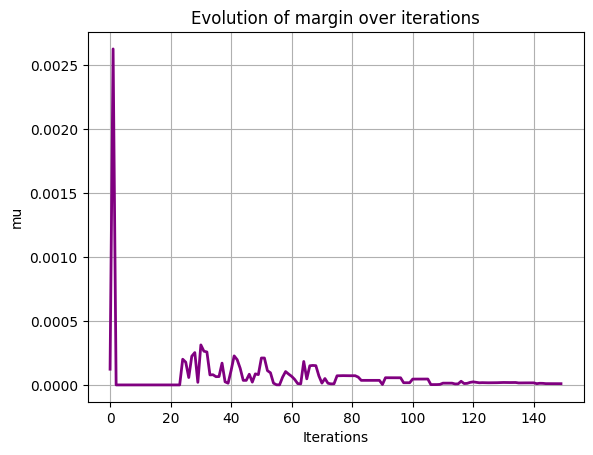

09:33:33 | INFO | machinemoo | Fit runtime: 1445.84 seconds


In [9]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = False)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[method] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

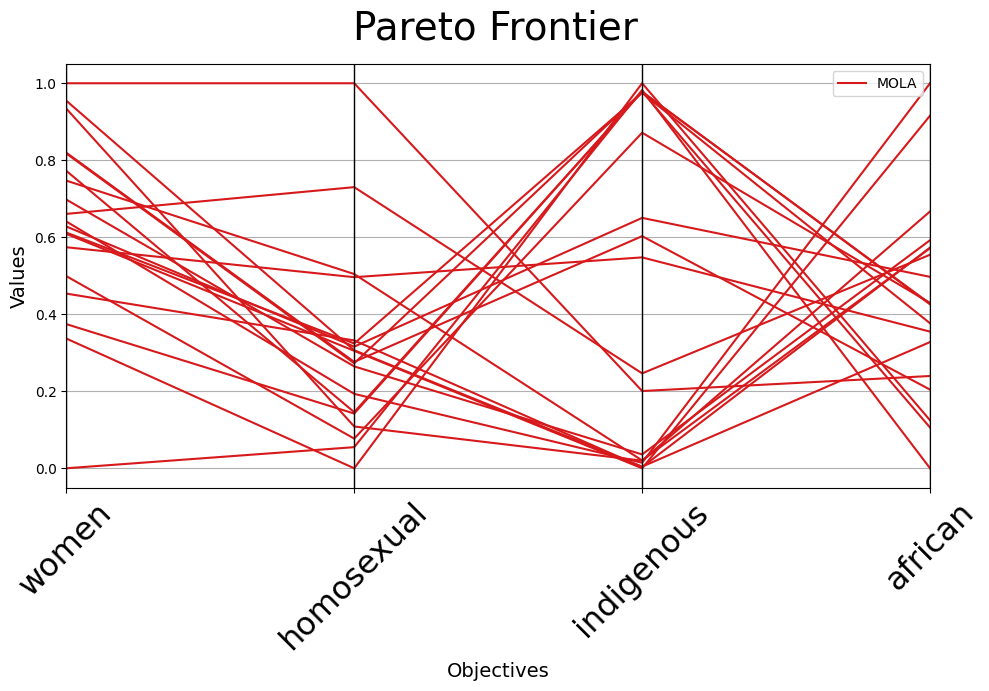

In [ ]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_mola.pdf'
            )

09:33:34 | DEBUG | machinemoo | Filtered parameters for Mola: {'node_time_limit': 2, 'target_size': 150, 'target_gap': 0, 'node_gap': 0.05, 'norm': False}
09:33:34 | DEBUG | machinemoo | Finding 1th individual minimum
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 103.40it/s]


Epoch 1 - Average loss: 0.1827


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 108.33it/s]


Epoch 2 - Average loss: 0.1781


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 105.60it/s]


...

Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 117.22it/s]


Epoch 3 - Average loss: 0.0945


09:55:50 | INFO | machinemoo | [Lipschitz] Updated global lower bounds: [0.20182792 0.16728154 0.00767693 0.13549499]


new solution dominated [0.3815219  0.2835622  0.0822916  0.35215716]


09:55:50 | DEBUG | machinemoo | Calculated weights: [0. 0. 0. 1.]
09:55:50 | DEBUG | machinemoo | Importance: 0.21566797969128648
09:55:50 | DEBUG | machinemoo | Global lower bound (y*): [0.20182792 0.16728154 0.00767693 0.13549499]
09:55:50 | DEBUG | machinemoo | Iteration 150
09:55:50 | DEBUG | machinemoo | Solutions list: [array([0.38049647, 0.28360804, 0.08071899, 0.35150977]), array([0.38070375, 0.28295692, 0.08067797, 0.35116297]), array([0.38032102, 0.28215214, 0.07925516, 0.35168952]), array([0.38045663, 0.28264176, 0.07910601, 0.35237018]), array([0.3805303 , 0.28286028, 0.07907022, 0.35208419]), array([0.38052379, 0.28297586, 0.07893734, 0.35195331]), array([0.38056421, 0.28204458, 0.07882493, 0.35181061]), array([0.38115997, 0.28270025, 0.07878866, 0.35191386]), array([0.38085405, 0.28199903, 0.07880389, 0.35231913]), array([0.38054833, 0.28263516, 0.07875369, 0.35211144]), array([0.38095451, 0.28199876, 0.07867047, 0.35249021]), array([0.3808305 , 0.28217165, 0.07859957, 0.

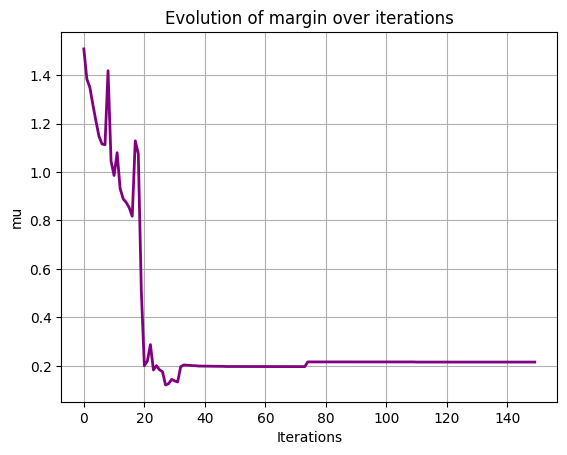

09:55:50 | INFO | machinemoo | Fit runtime: 1335.85 seconds


In [11]:
method = 'mola'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = moopt.get_hypervolumes()
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

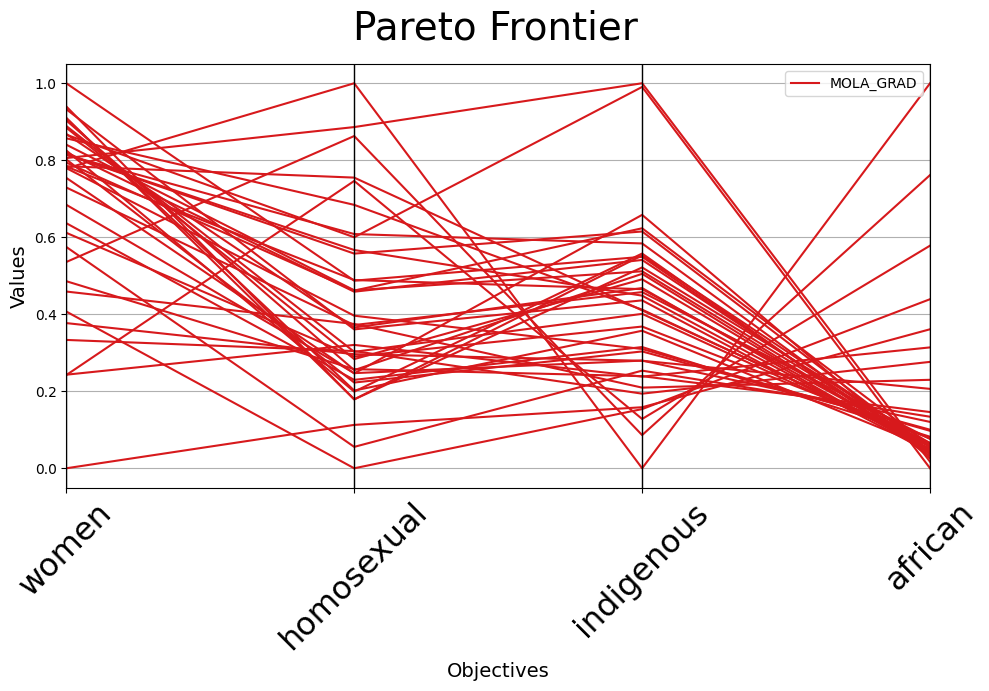

In [ ]:
title="Loss Trade-offs in Multi-Group Hate Speech Detection"
plot_pareto(methods={'mola_grad': objs},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_mola_grad.pdf'
            )

### Random Weight

In [13]:
method = 'random_weight'
w_scalar = NLPScalarization(train_dataloader = train_dataloader, 
                            device = device, 
                            task_names = task_names, 
                            gradient = True)
moopt = moo(w_scalar).mo_optimization(method, **opt_params)
objs = get_objectives(moopt)
hypervolume_values = compute_hypervolume_progress(objs)
results[f'{method}_grad'] = {
                "moopt": moopt,
                "objectives": objs,
                "models": get_models(moopt),
                "hypervolume": hypervolume_values
            }

09:55:50 | WARNING | machinemoo | Ignored parameters for random_weights: {'nodeTimeLimit', 'targetGap', 'nodeGap'}
09:55:50 | DEBUG | machinemoo | Filtered parameters for random_weights: {'targetSize': 150, 'norm': False}
09:55:50 | DEBUG | machinemoo | Finding 1th individual minima
Epoch 1/3: 100%|██████████| 241/241 [00:02<00:00, 105.49it/s]


Epoch 1 - Average loss: 0.1529


Epoch 2/3: 100%|██████████| 241/241 [00:02<00:00, 107.75it/s]


Epoch 2 - Average loss: 0.1484


Epoch 3/3: 100%|██████████| 241/241 [00:02<00:00, 110.72it/s]


...

Epoch 2/3: 100%|██████████| 241/241 [00:04<00:00, 50.66it/s]


Epoch 2 - Average loss: 0.0681


Epoch 3/3: 100%|██████████| 241/241 [00:04<00:00, 49.89it/s]


Epoch 3 - Average loss: 0.0675


10:39:34 | DEBUG | machinemoo | 150th solution


## A posteriori Decision Making

* Comparison between MOO methods
* Ensemble and Evaluation

In [14]:
from machinemoo.analysis.visualization import plot_multiple_hypervolumes

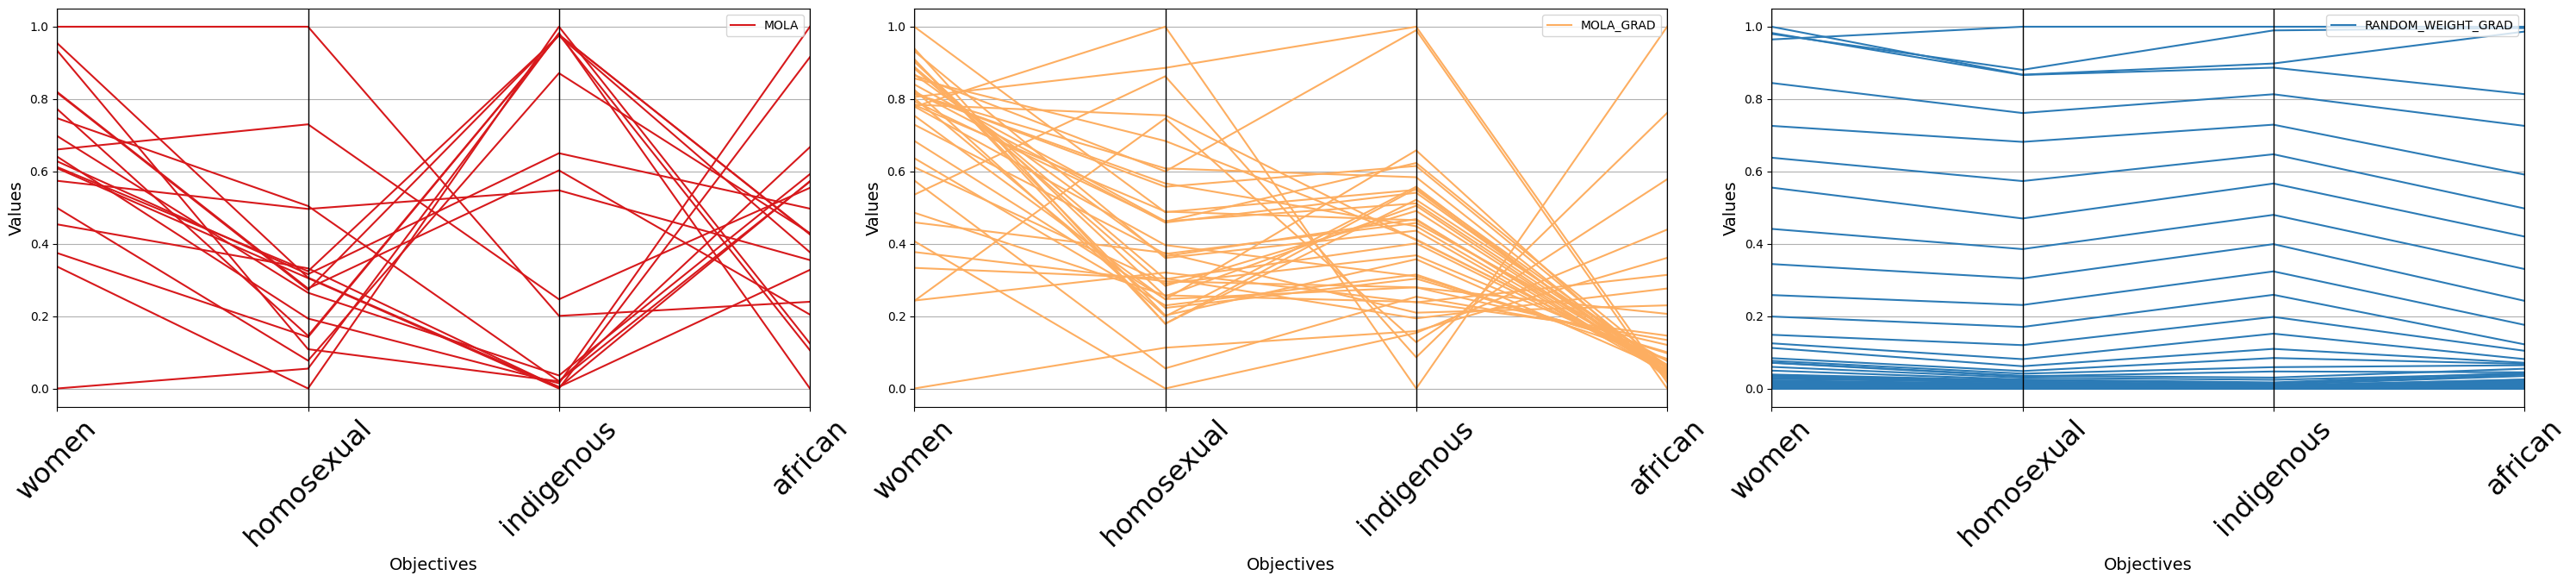

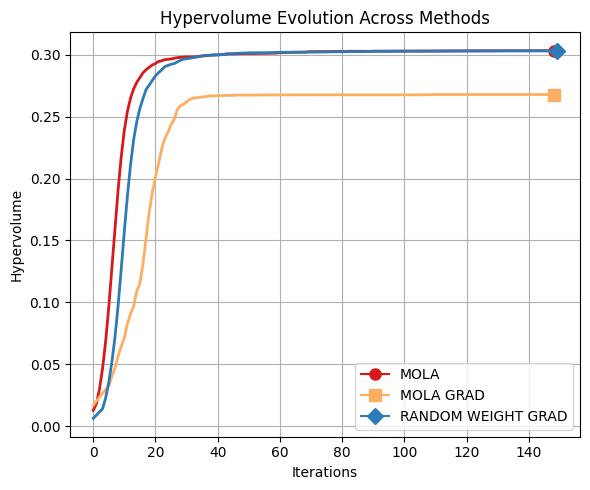

In [37]:
pareto_dict = {
        method: res["objectives"]
        for method, res in results.items()
        if "objectives" in res
    }

hypervolumes_dict = {
        method: res["hypervolume"]
        for method, res in results.items()
        if "hypervolume" in res
    }

plot_pareto(methods=pareto_dict,
            labels=task_names, 
            title="",
            fontsize=23,
            figsize=(10,7),
            save_path='images/4_objs_methods.pdf'
            )
plot_multiple_hypervolumes(methods_hv=hypervolumes_dict)

In [16]:
from machinemoo.analysis.decision import get_best_median_solution, get_best_weighted_solution

In [40]:
res = get_best_median_solution(results['mola_grad']['objectives'], results['mola_grad']['models'])

In [41]:
res

(array([0.57486598, 0.05559469, 0.25358697, 0.13388631]),
 MultiTaskModel(
   (dropout): Dropout(p=0.3, inplace=False)
   (shared_fc): Linear(in_features=50, out_features=32, bias=True)
   (classifiers): ModuleDict(
     (women): Linear(in_features=32, out_features=2, bias=True)
     (homosexual): Linear(in_features=32, out_features=2, bias=True)
     (indigenous): Linear(in_features=32, out_features=2, bias=True)
     (african): Linear(in_features=32, out_features=2, bias=True)
   )
 ),
 np.float64(0.19373663810000602),
 28)

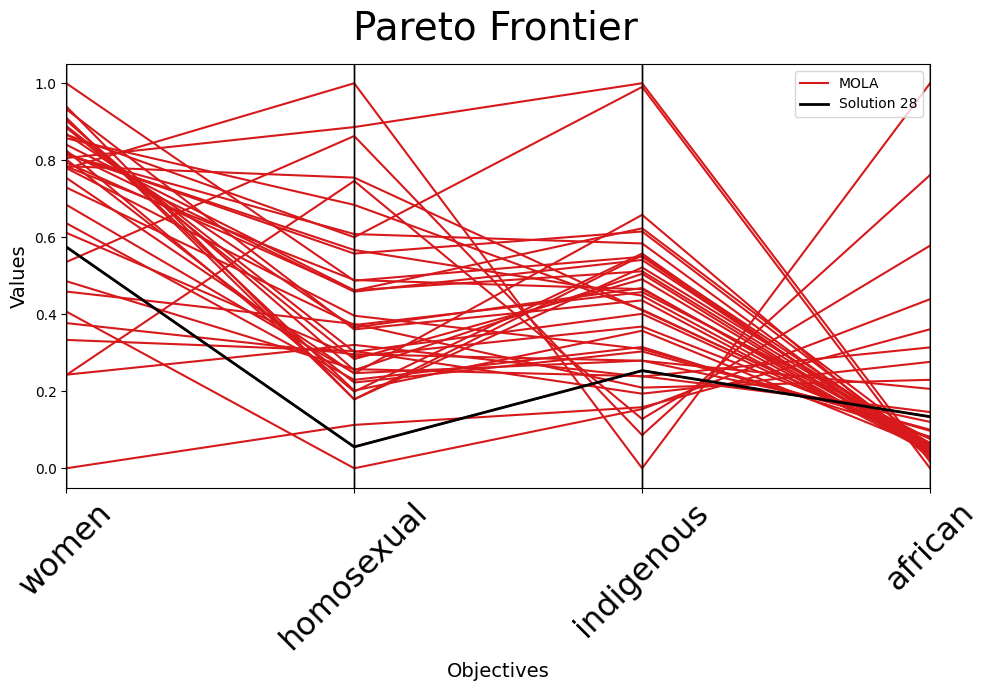

In [ ]:
plot_pareto(methods={'mola': results['mola_grad']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=23,
            figsize=(10,7),
            point=res[0],
            point_label=f'Solution {res[3]}',
            save_path='images/4_objs_methods_median.pdf'
            )

In [46]:
res = get_best_weighted_solution(results['mola']['objectives'], results['mola']['models'], [0.2, 0.4, 0.2, 0.2])

In [47]:
res

(array([0.45370728, 0.3320418 , 0.00308985, 0.57308651]),
 MultiTaskModel(
   (dropout): Dropout(p=0.3, inplace=False)
   (shared_fc): Linear(in_features=50, out_features=32, bias=True)
   (classifiers): ModuleDict(
     (women): Linear(in_features=32, out_features=2, bias=True)
     (homosexual): Linear(in_features=32, out_features=2, bias=True)
     (indigenous): Linear(in_features=32, out_features=2, bias=True)
     (african): Linear(in_features=32, out_features=2, bias=True)
   )
 ),
 np.float64(0.33879344735160843),
 0)

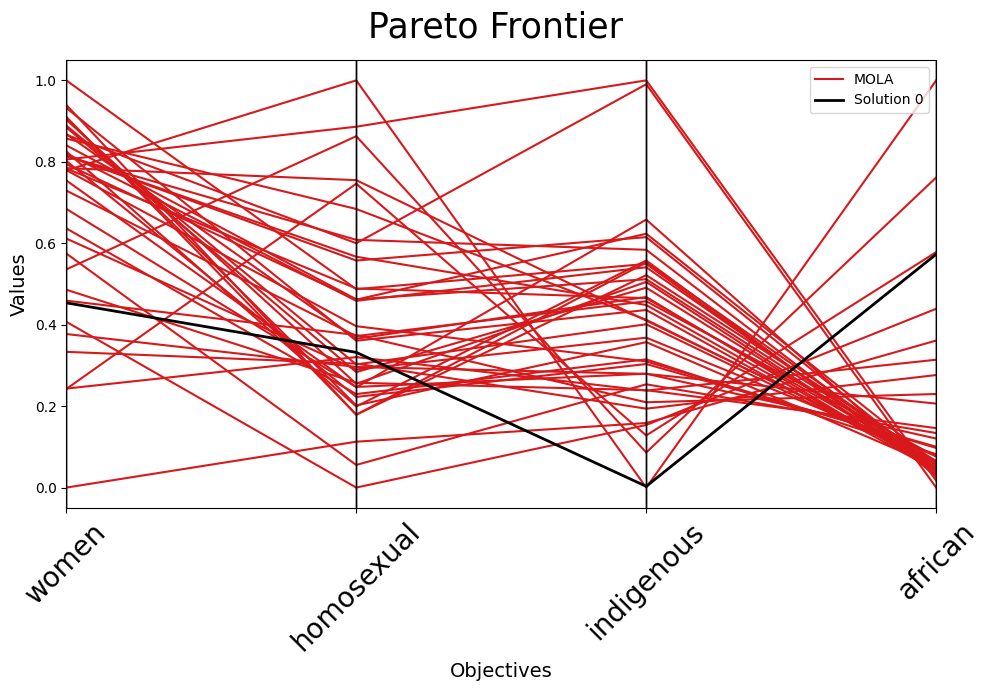

In [ ]:
plot_pareto(methods={'mola': results['mola_grad']['objectives']},
            labels=task_names, 
            title=title,
            fontsize=20,
            figsize=(10,7),
            point=res[0],
            point_label=f'Solution {res[3]}',
            save_path='images/4_objs_methods_weighted.pdf'
            )